# ATCoder — Graph and Spectral Analysis

Graph/spectral coverage plus sampled PSS and Wasserstein score distributions.


In [11]:
from pathlib import Path
import sys
for candidate in [Path.cwd(), *Path.cwd().parents]:
    if (candidate / 'spectral_code').exists():
        PROJECT_ROOT = candidate
        break
else:
    raise RuntimeError('Open this notebook from the repository.')
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import importlib
import spectral_code.evaluation.atcoder_analysis as atcoder_analysis
importlib.reload(atcoder_analysis)
from spectral_code.evaluation.atcoder_analysis import *

sns.set_theme(style='whitegrid', context='notebook')
ROOT = clean_data_dir()
ROOT


WindowsPath('C:/Users/koush/PyProjects/spectrals/outputs/atcoder/clean_data')

In [12]:
coverage, summary = graph_coverage(ROOT)
summary
coverage


,language,graph_type,spectral_status,codes,empty_eigenvalue_layers
0,java,ast,ok,20810,0
1,java,cfg,ok,20810,0
2,java,cpg,ok,20810,0
3,java,ddg,missing_or_empty_graph,12,12
4,java,ddg,ok,20798,0
5,python,ast,ok,22312,0
6,python,ast,ok_sparse_topk,1,0
7,python,cfg,ok,22313,144
8,python,cpg,ok,22310,0
9,python,cpg,ok_sparse_topk,3,0


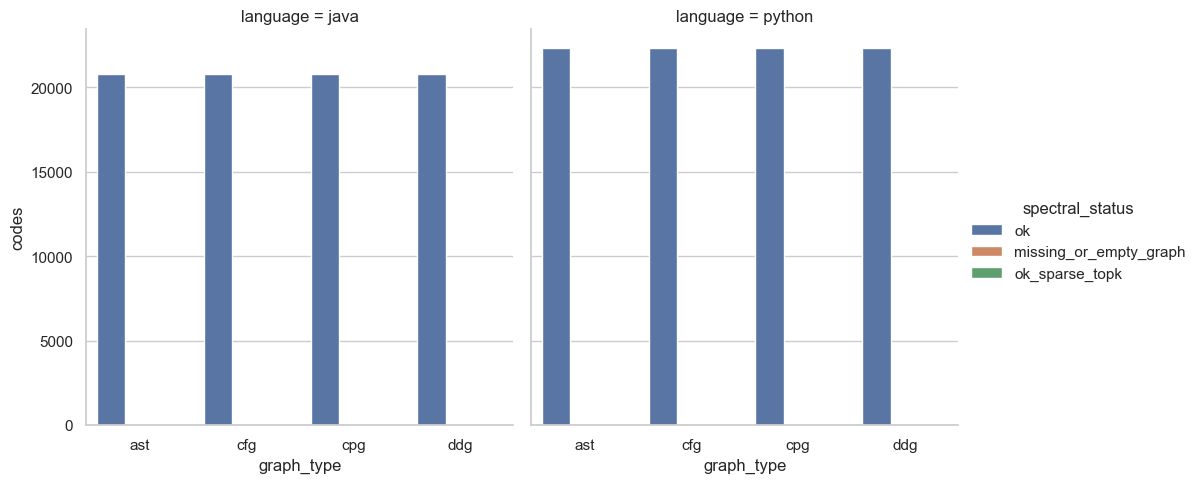

In [13]:
sns.catplot(data=coverage, x='graph_type', y='codes', hue='spectral_status', col='language', kind='bar'); plt.show()


## Clone and non-clone examples: code, graph, and spectrum


,split,left_id,right_id,label,label_name
0,train,8025,6396,1,clone


c:\Users\koush\PyProjects\spectrals\Spectral-Software\spectral_code\evaluation\atcoder_analysis.py:205: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans Mono.
  figure.tight_layout()
C:\Users\koush\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans Mono.
  fig.canvas.print_figure(bytes_io, **kw)


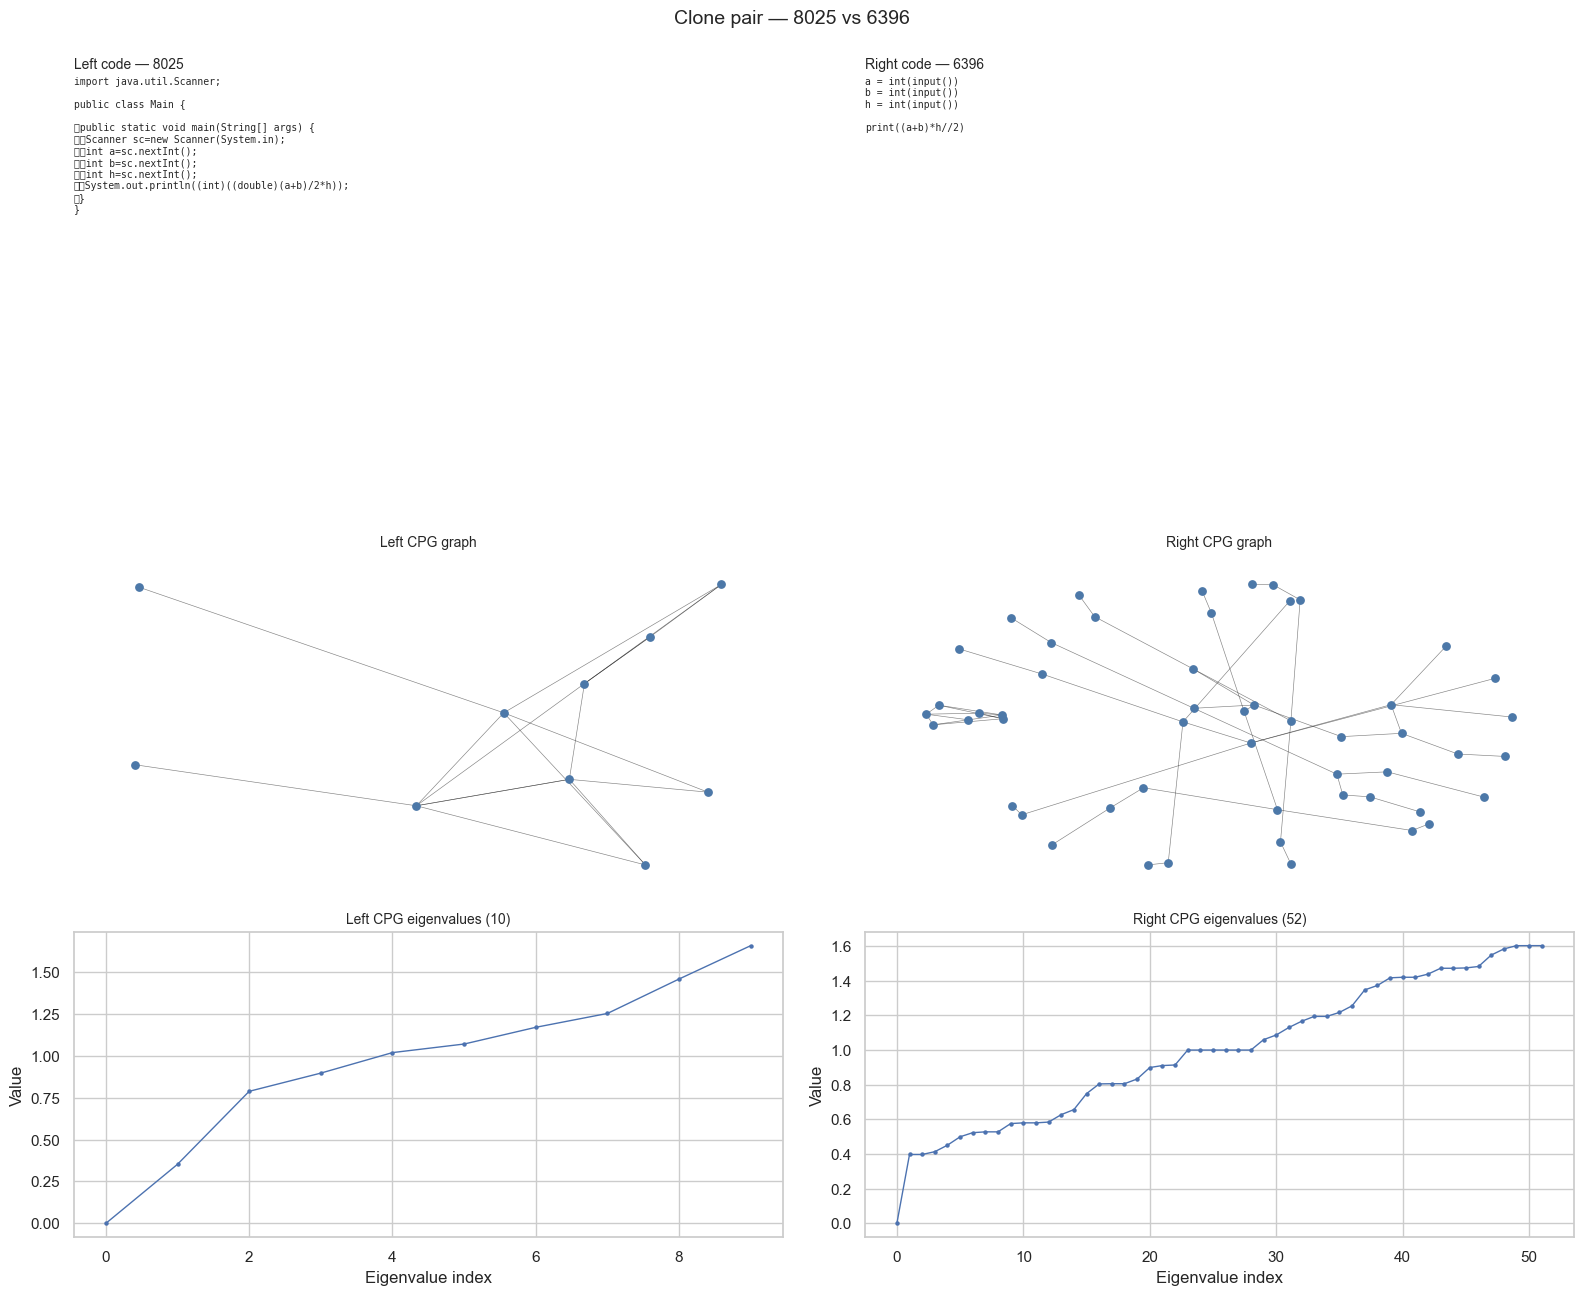

,split,left_id,right_id,label,label_name
0,train,31963,40661,1,clone


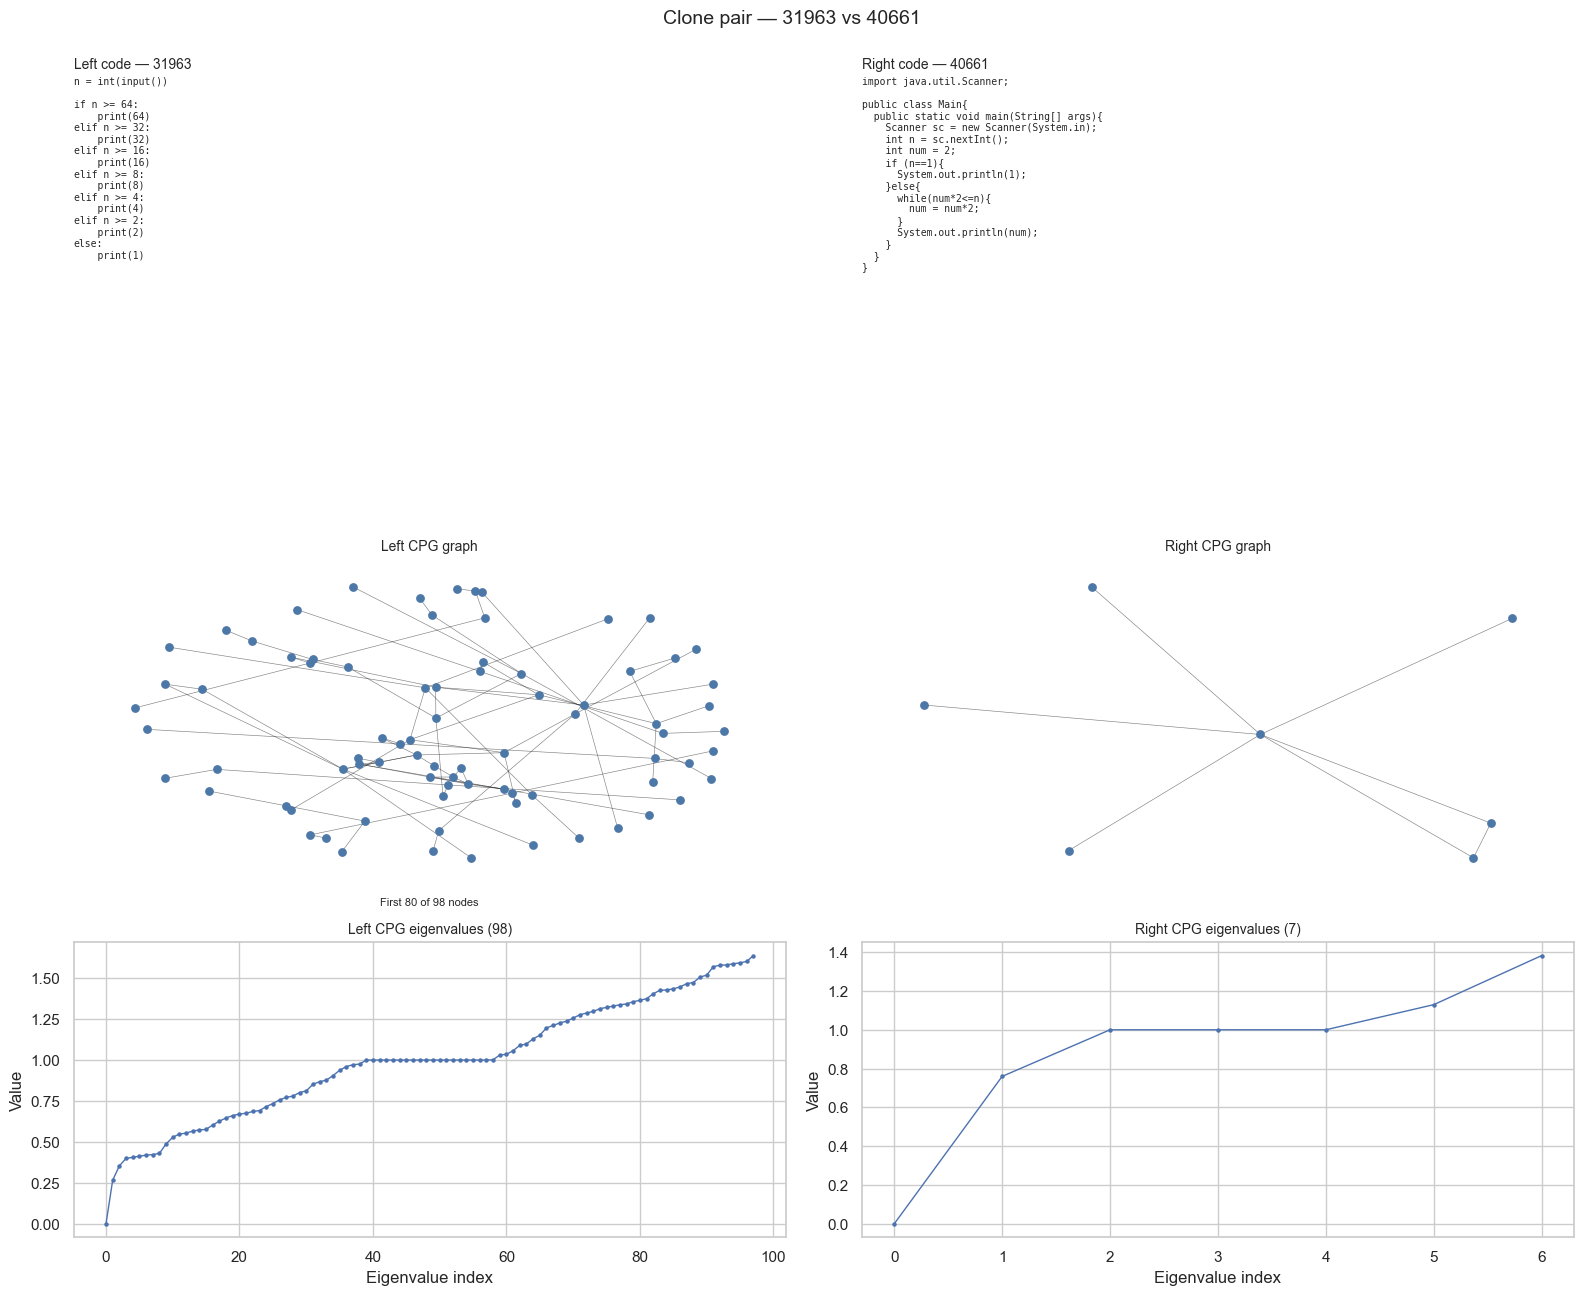

,split,left_id,right_id,label,label_name
0,train,31576,29234,0,non_clone


c:\Users\koush\PyProjects\spectrals\Spectral-Software\spectral_code\evaluation\atcoder_analysis.py:205: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans Mono.
  figure.tight_layout()
C:\Users\koush\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans Mono.
  fig.canvas.print_figure(bytes_io, **kw)


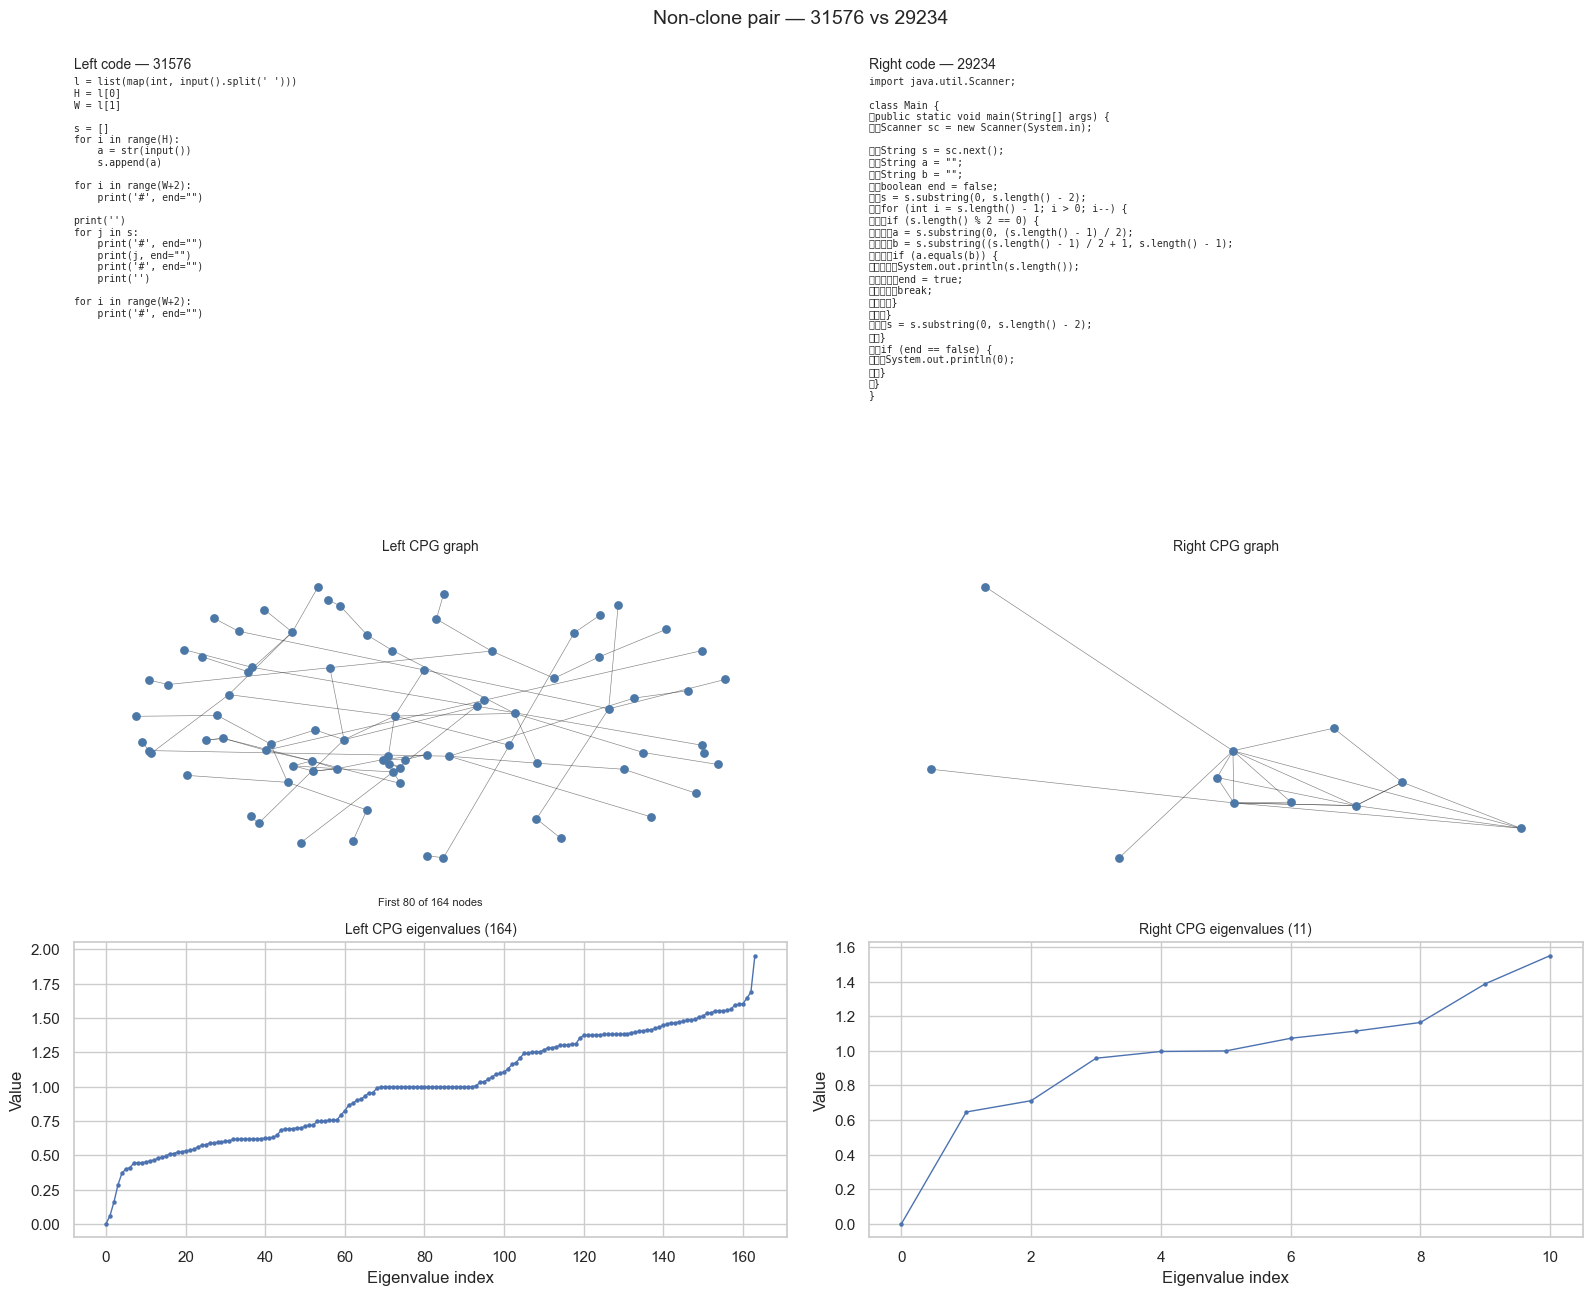

,split,left_id,right_id,label,label_name
0,train,11628,19576,0,non_clone


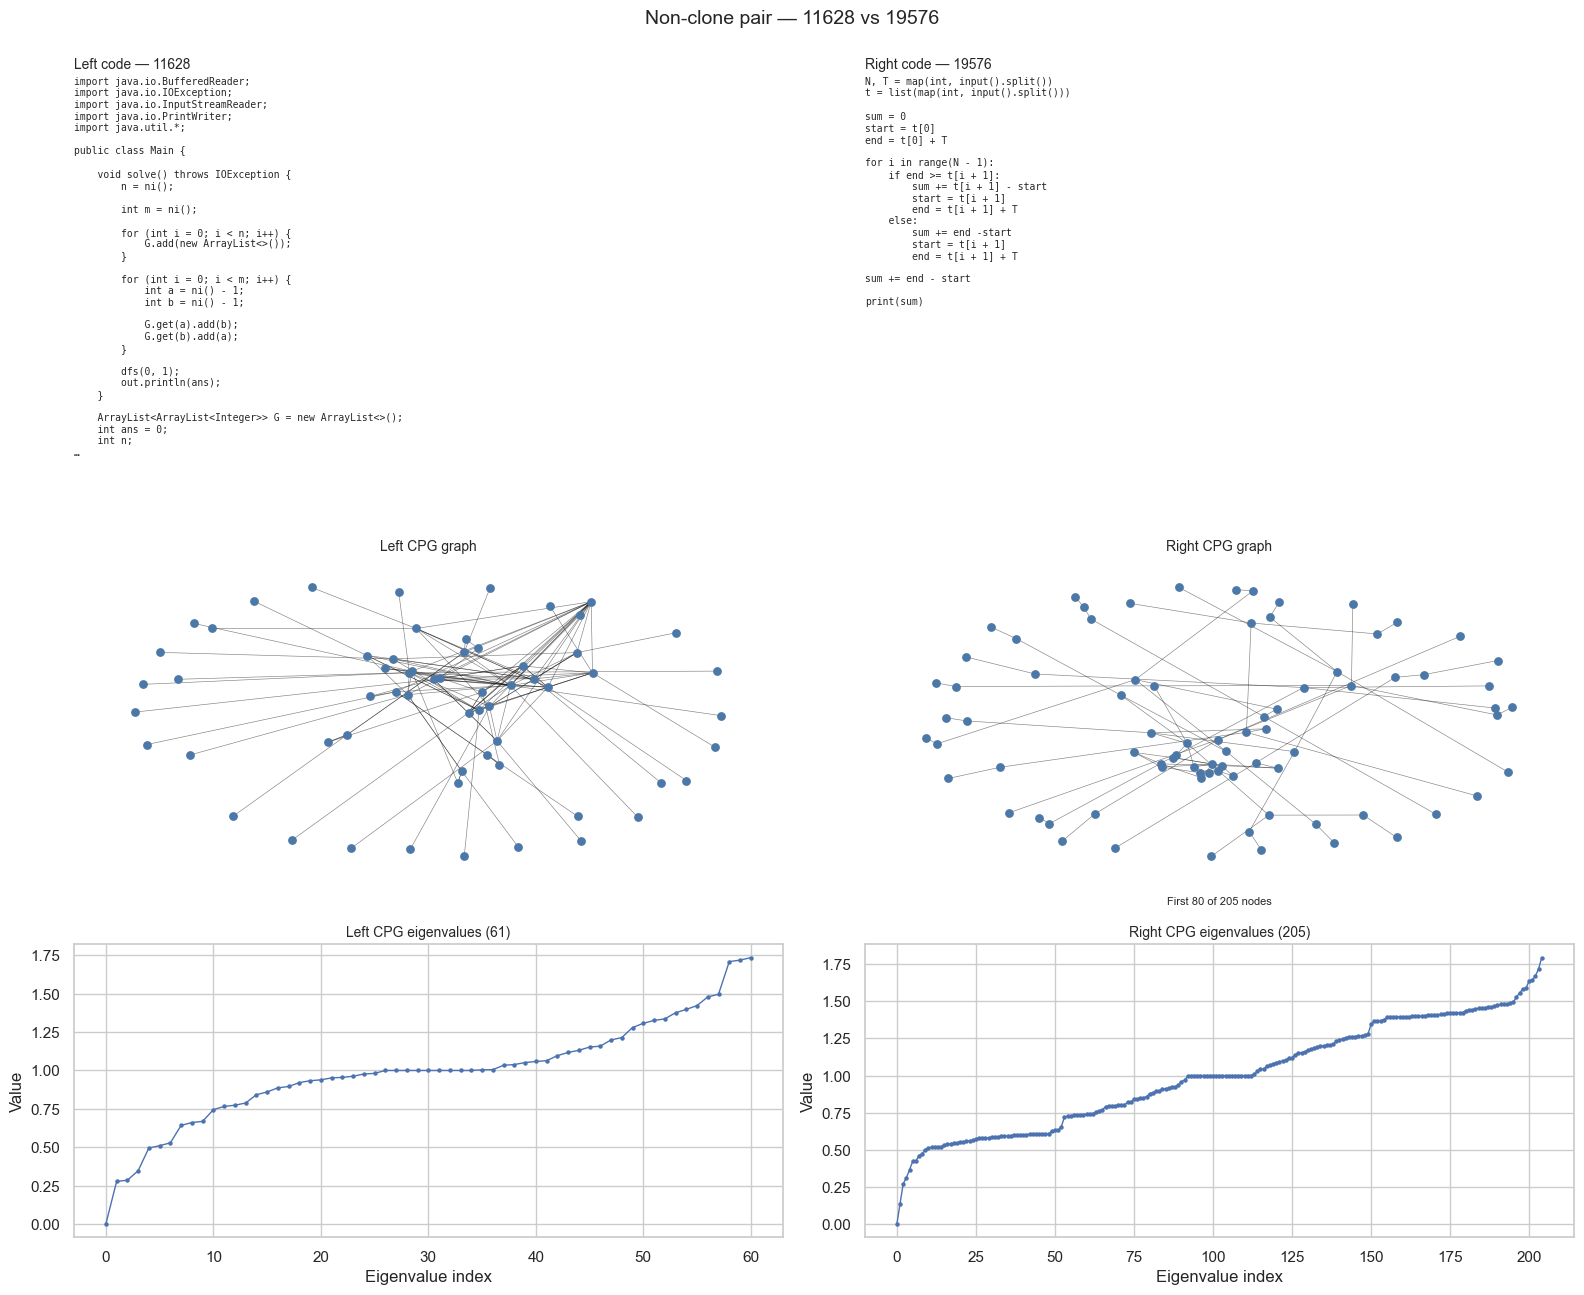

C:\Users\koush\AppData\Roaming\Python\Python312\site-packages\IPython\core\events.py:82: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans Mono.
  func(*args, **kwargs)
C:\Users\koush\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans Mono.
  fig.canvas.print_figure(bytes_io, **kw)


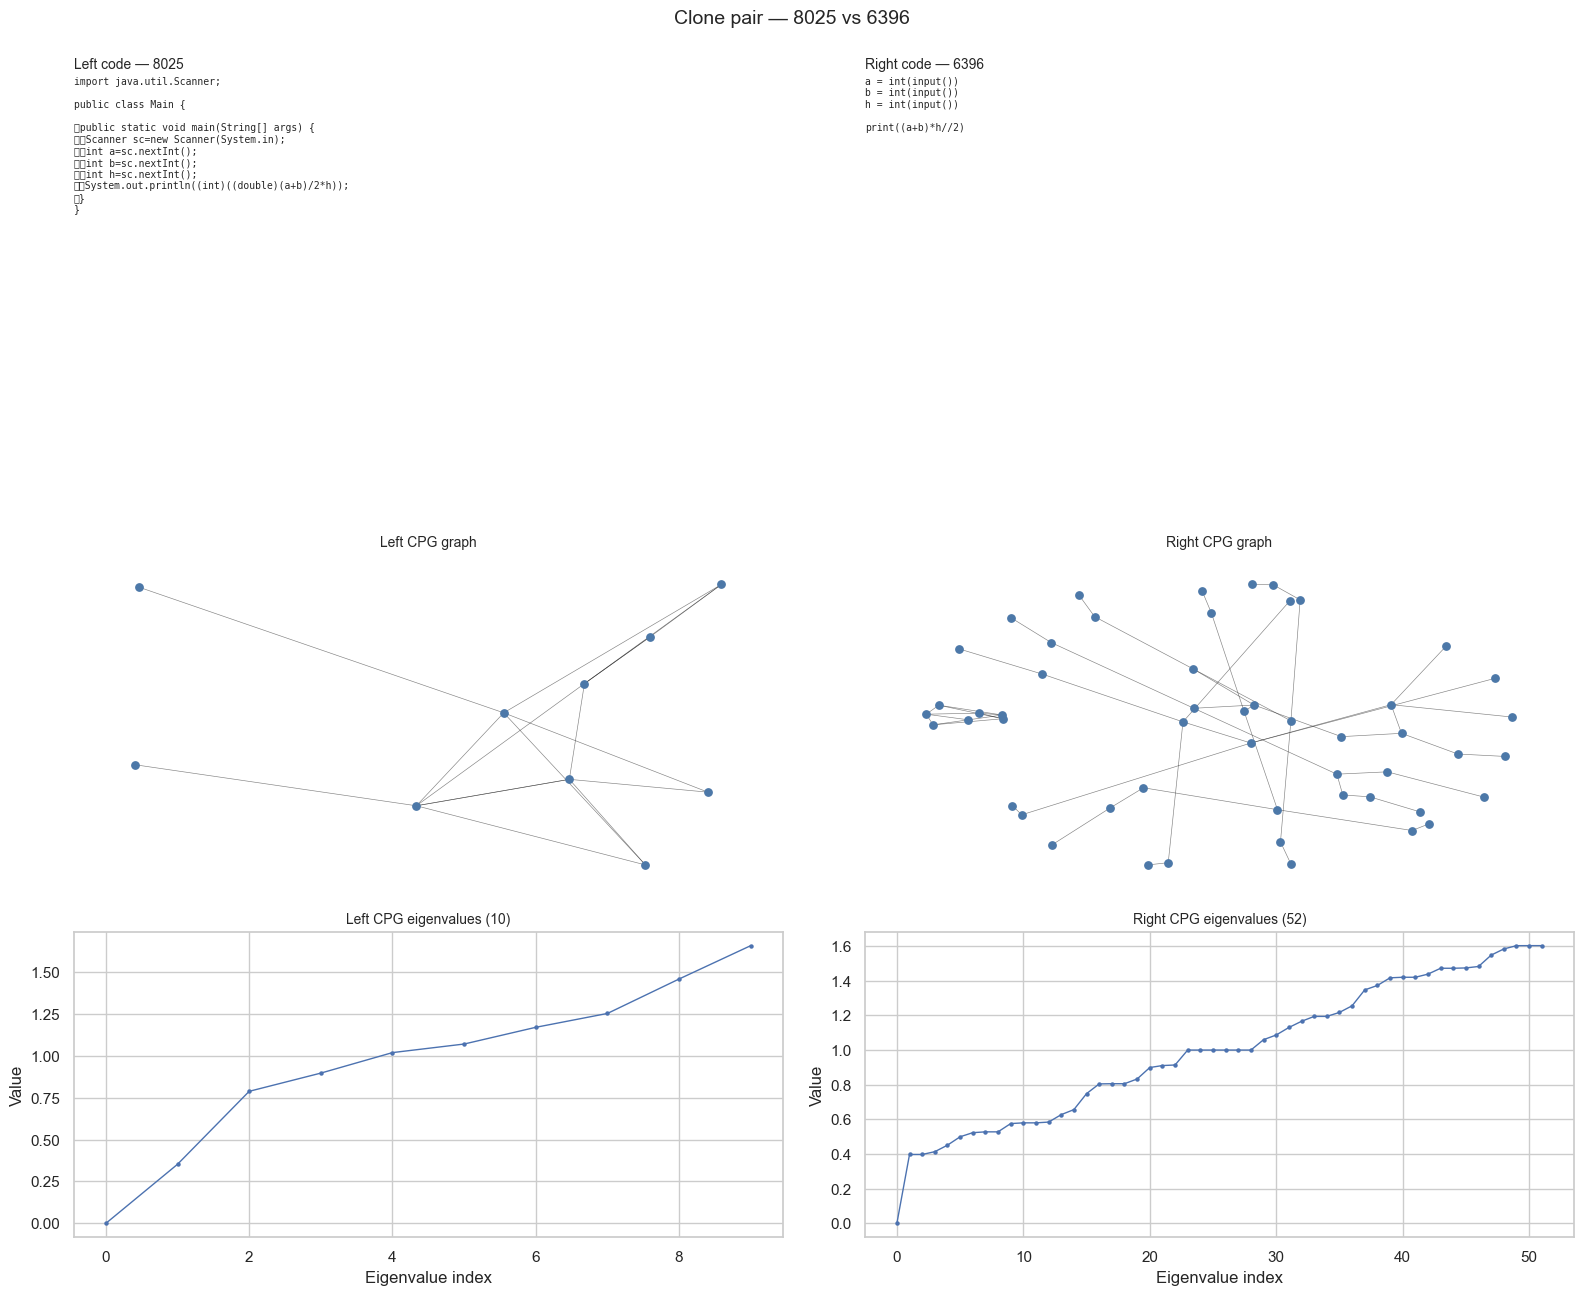

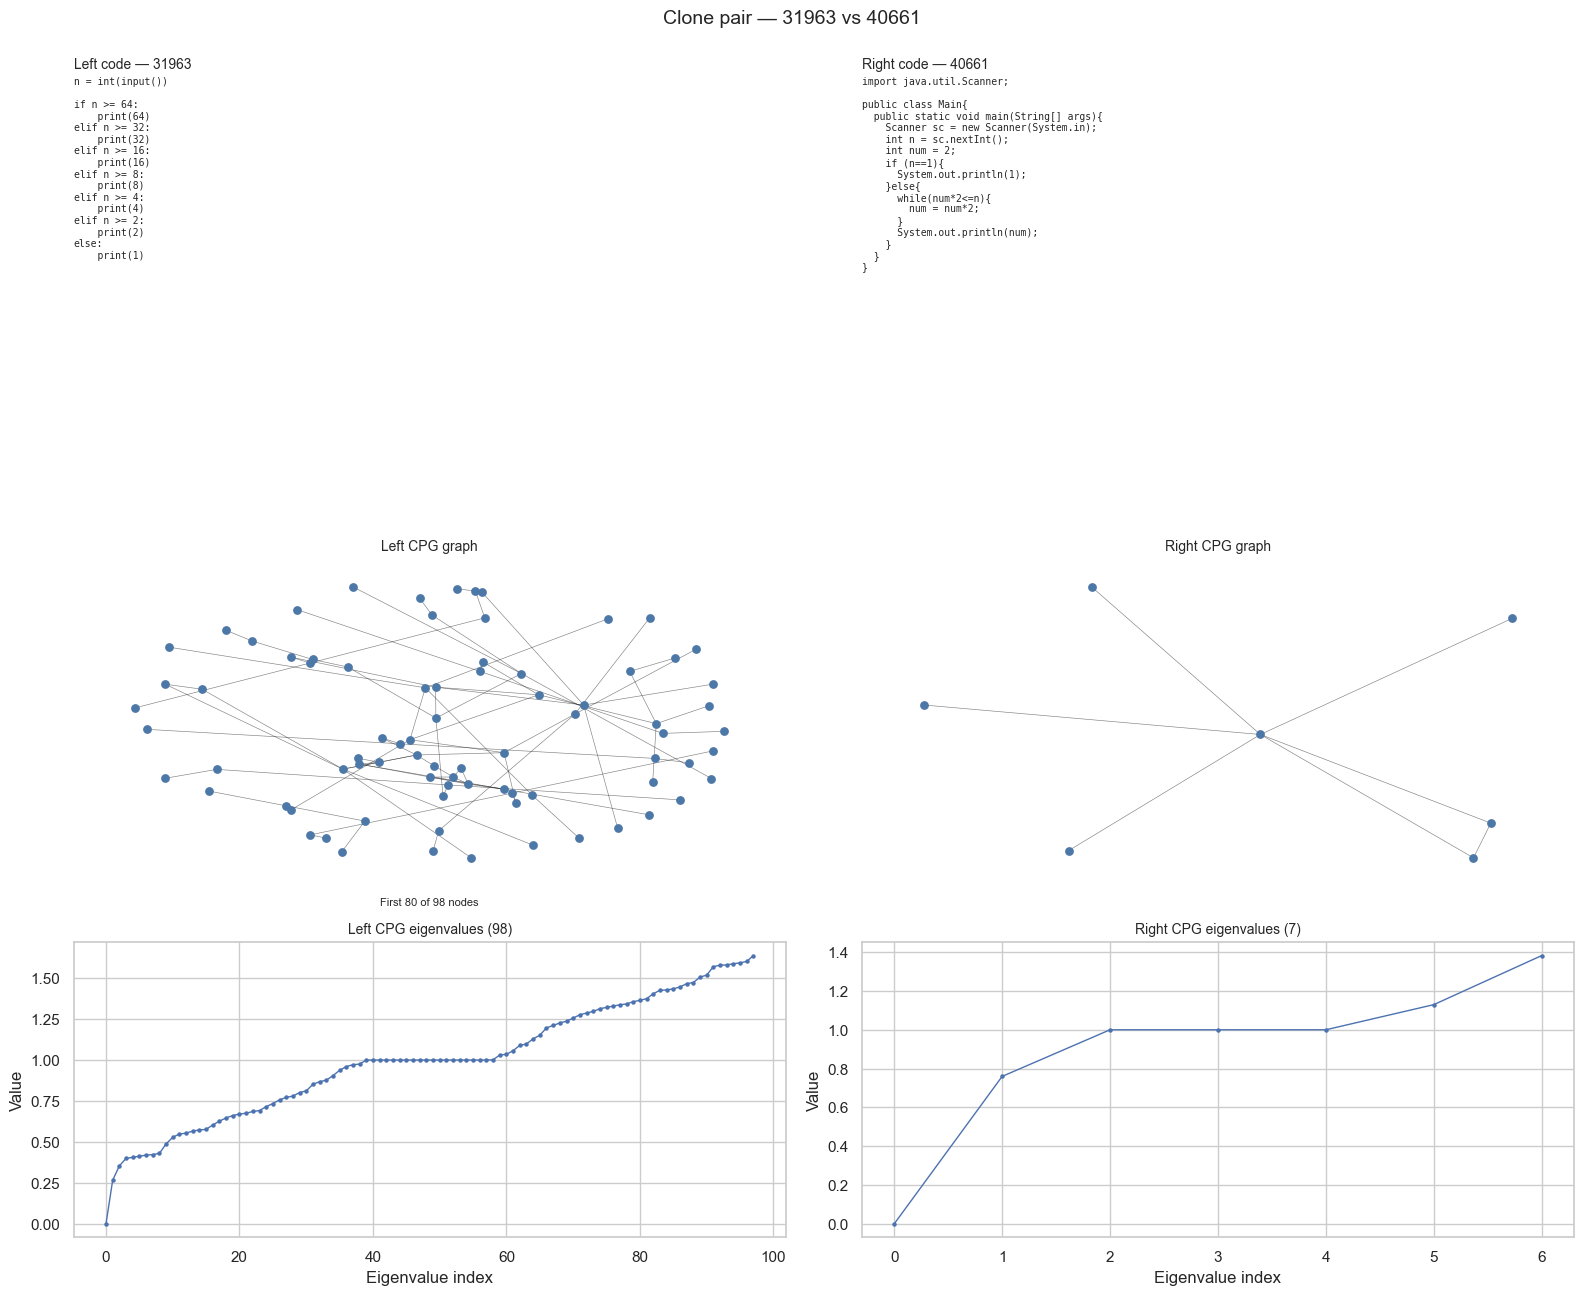

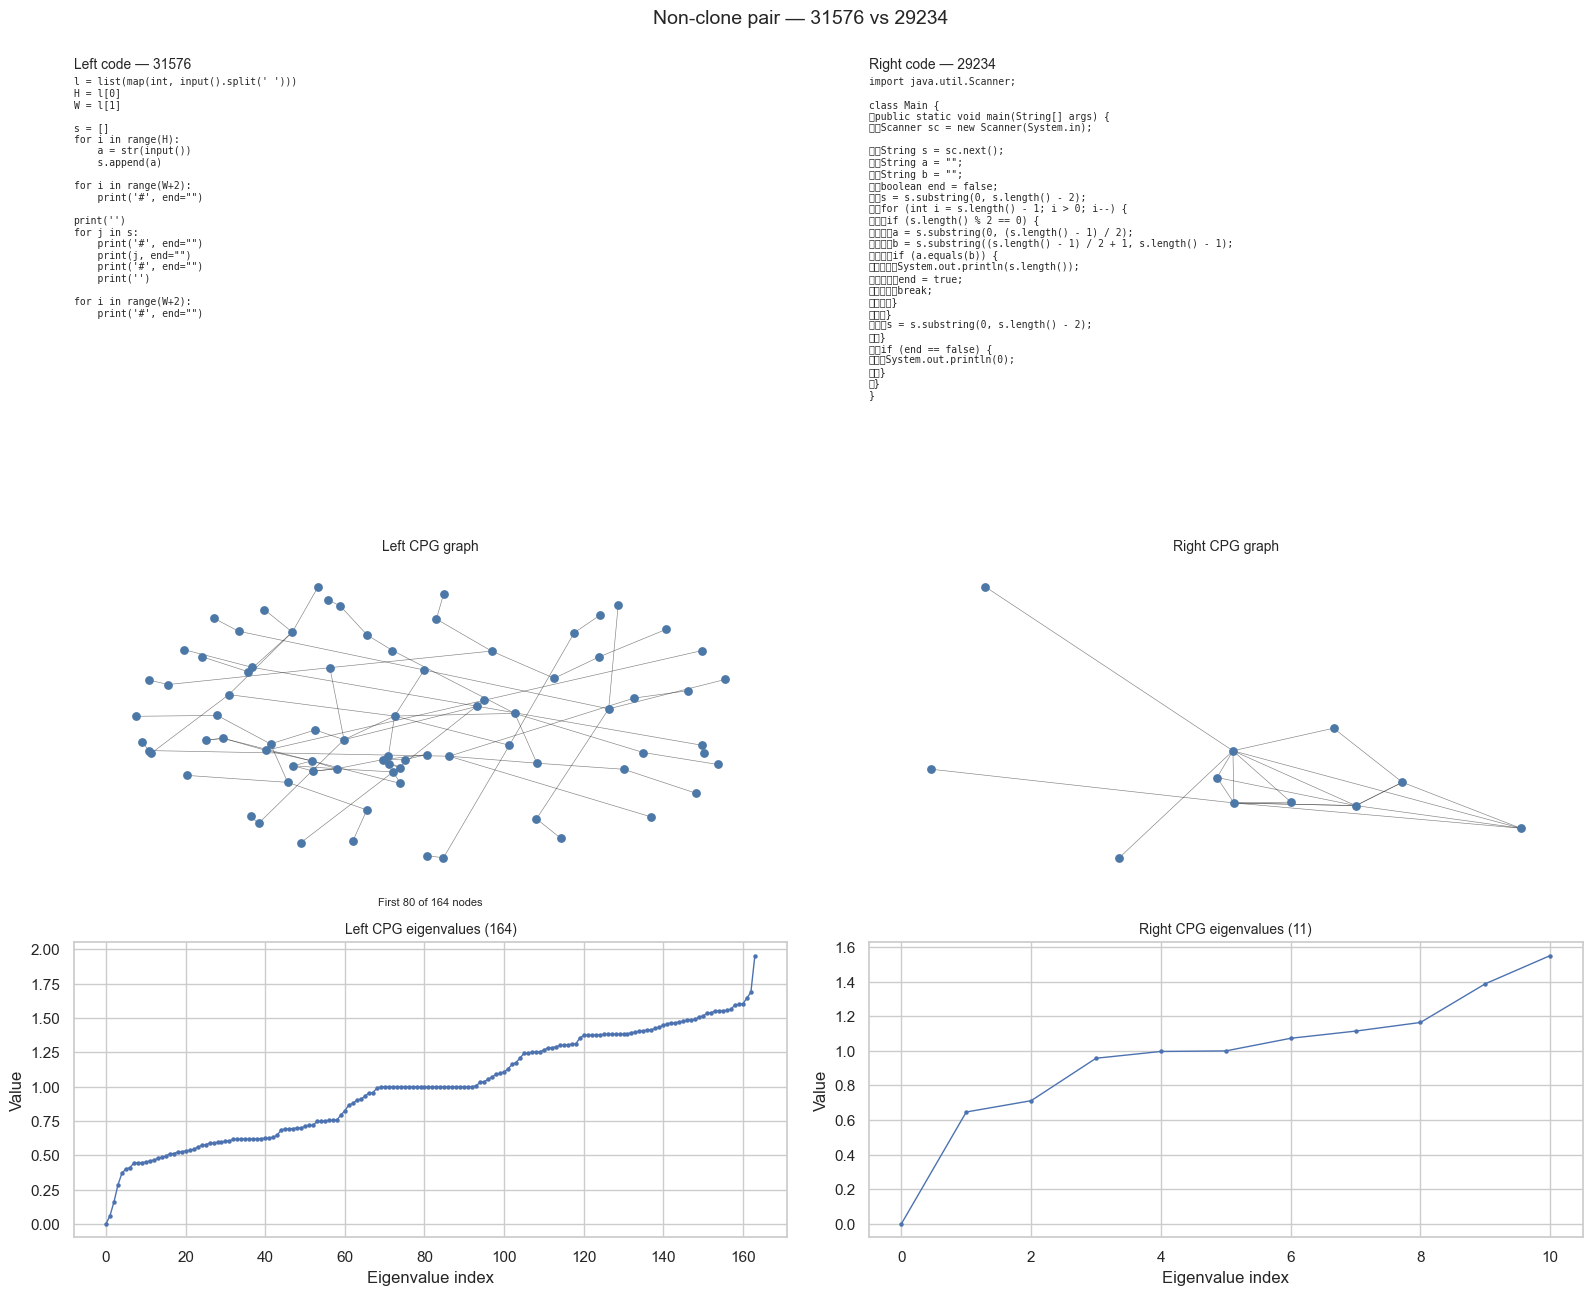

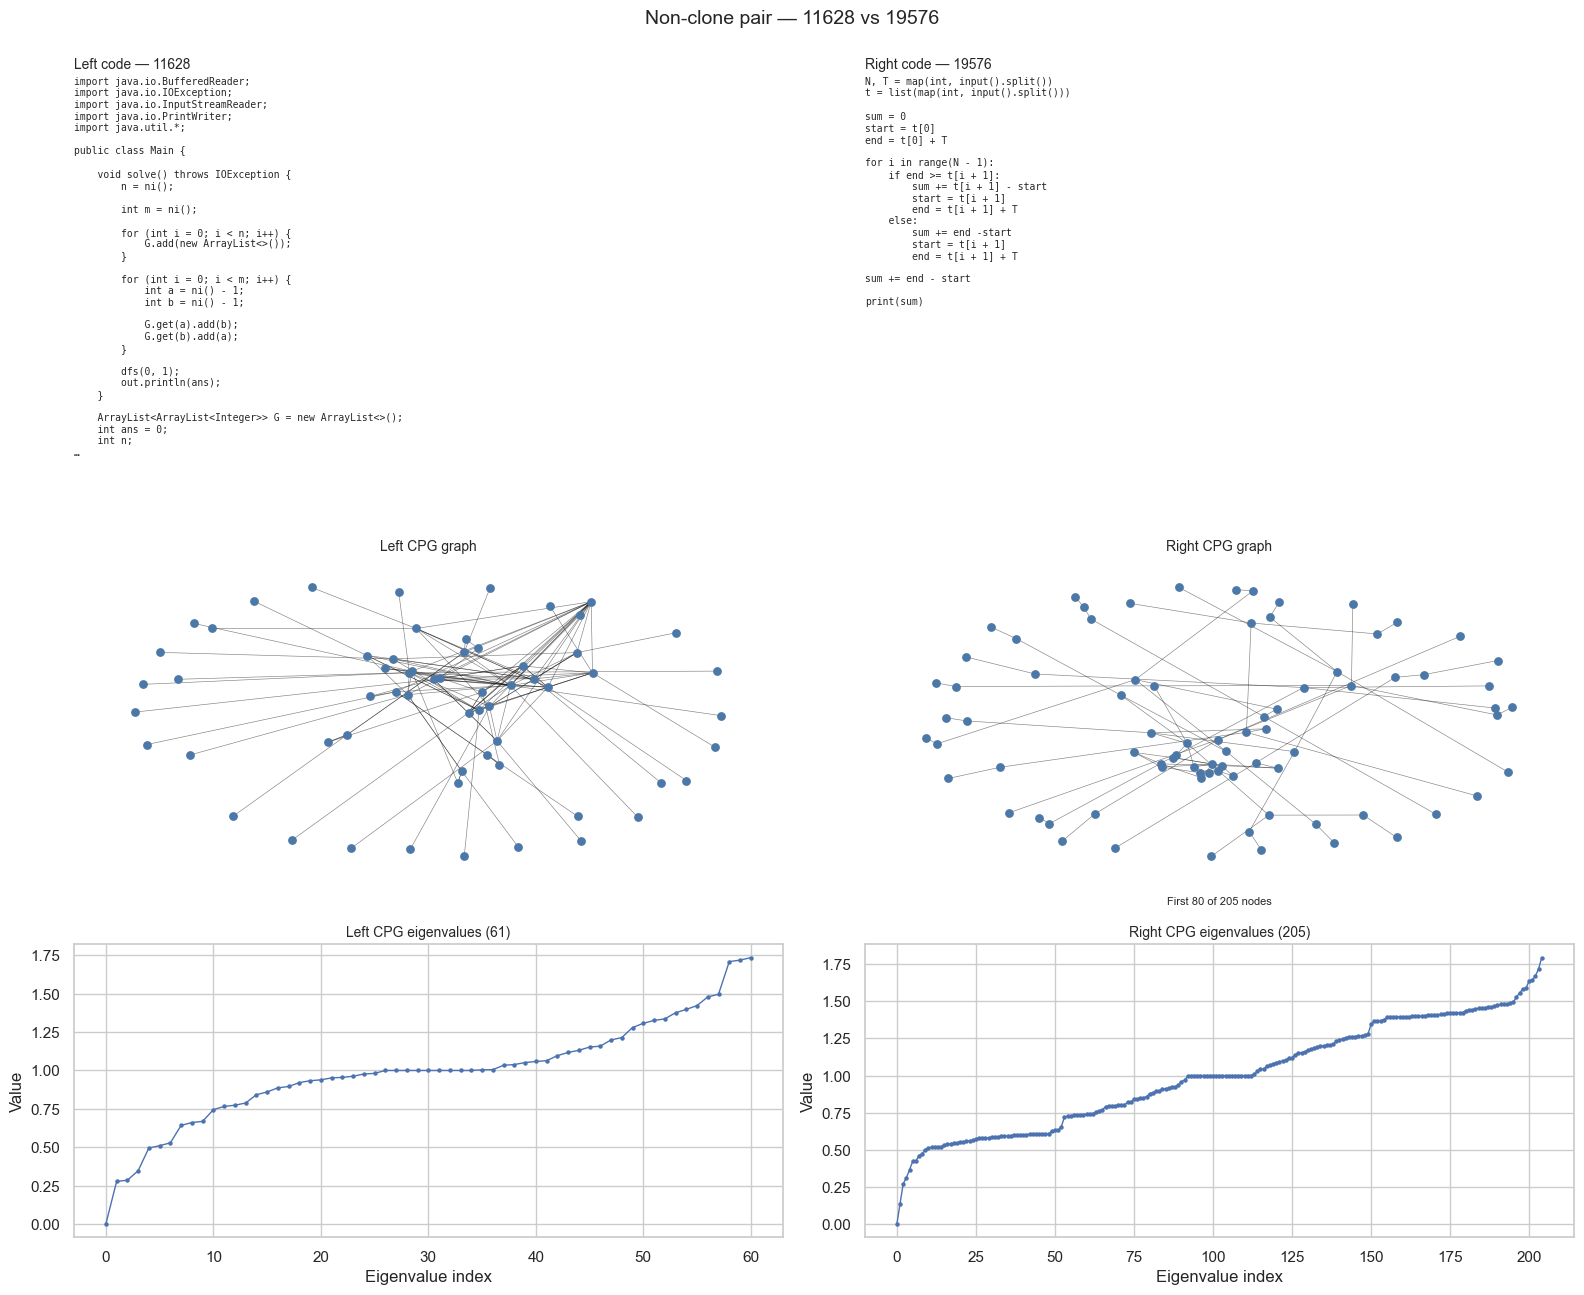

In [14]:
examples = select_pair_examples(ROOT, graph_type='cpg', per_label=2, seed=42)
for example in examples:
    display(pd.DataFrame([example['pair']]))
    display(plot_pair_code_graph_spectra(ROOT, example, graph_type='cpg', max_code_lines=32, max_graph_nodes=80))


## Balanced train-pair sample


In [15]:
scores = sample_similarity_scores(ROOT, sample_size=10_000, seed=42)
scores.groupby(['graph_type', 'label_name']).size().rename('scores').to_frame()


scores
graph_type label_name        
ast        clone         5000
           non_clone     5000
cfg        clone         4970
           non_clone     4968
cpg        clone         5000
           non_clone     5000
ddg        clone         4996
           non_clone     4999

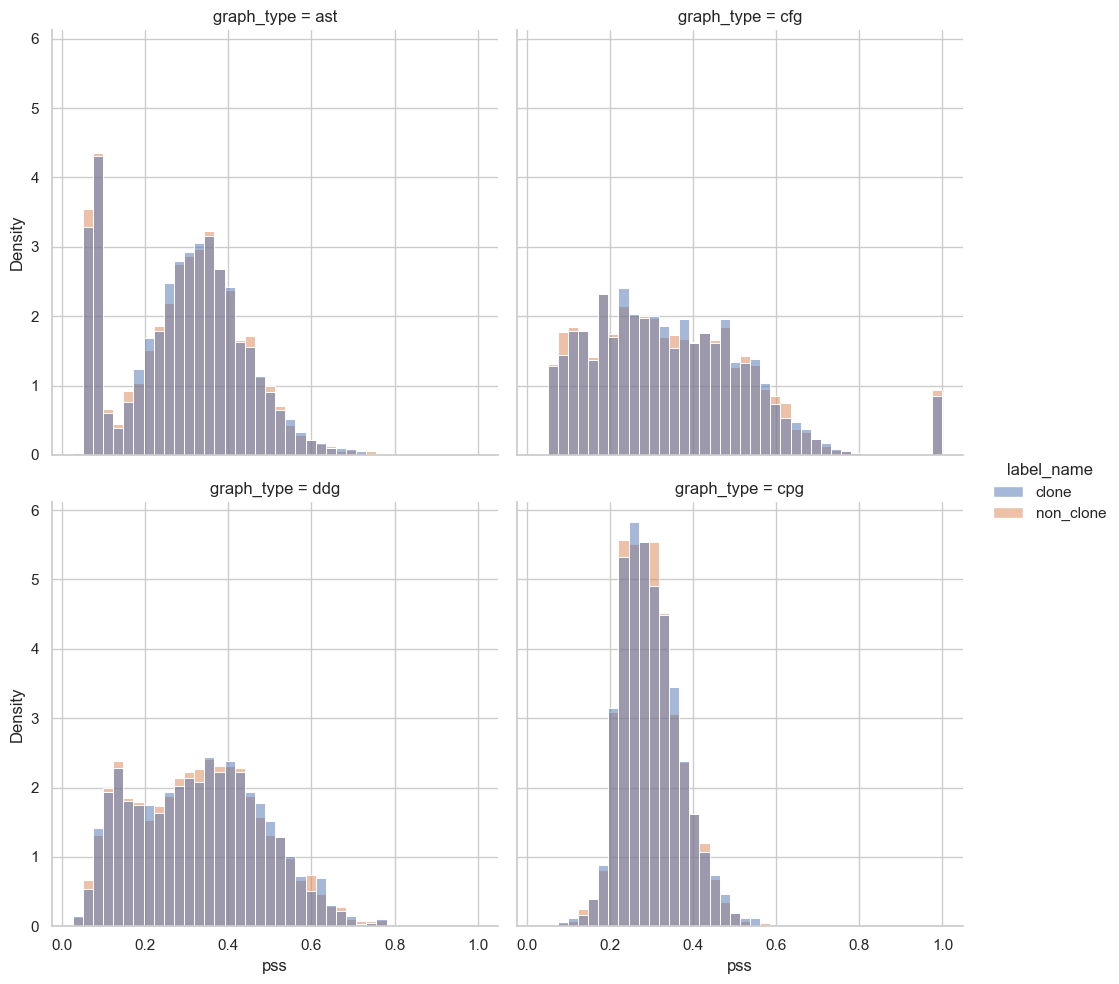

In [16]:
sns.displot(data=scores, x='pss', hue='label_name', col='graph_type', kind='hist', stat='density', common_norm=False, bins=40, col_wrap=2); plt.show()


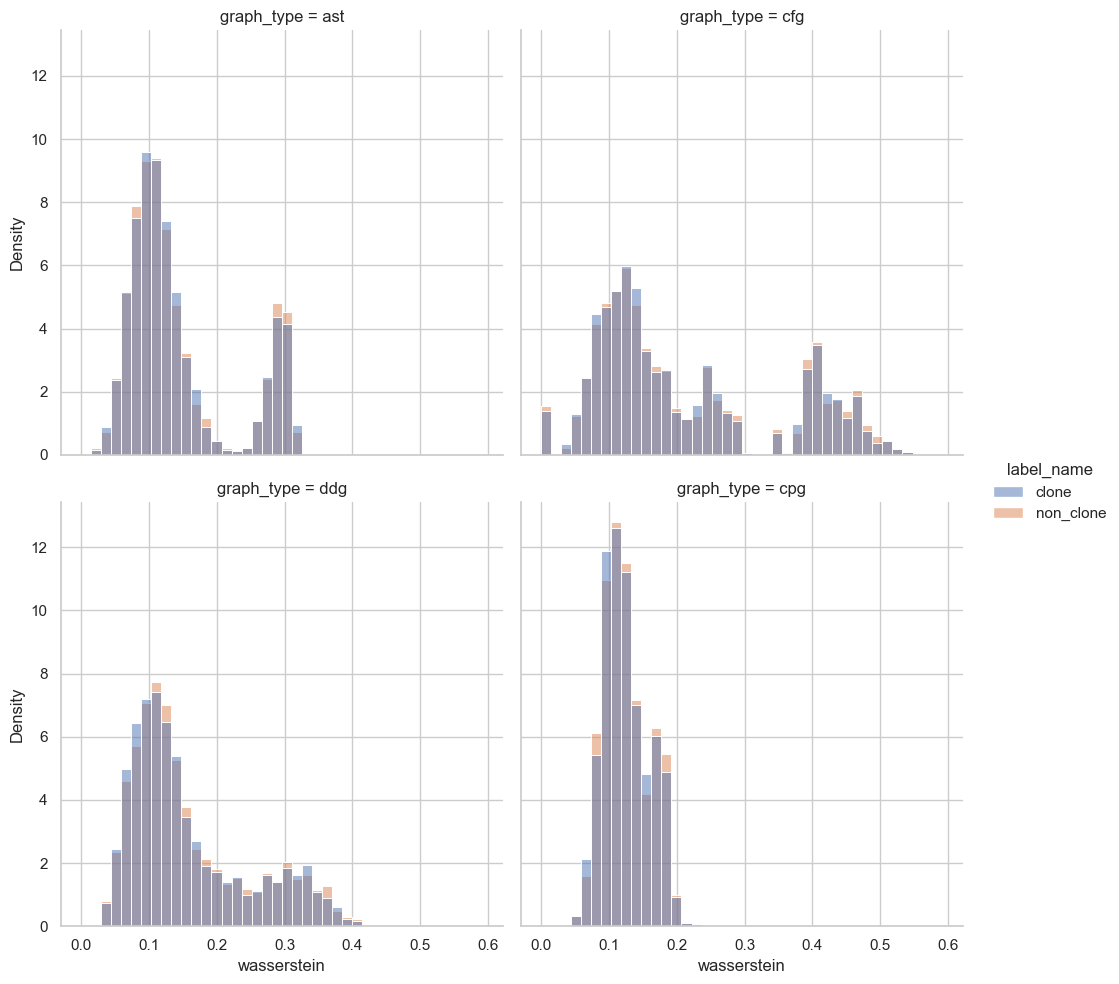

In [17]:
sns.displot(data=scores, x='wasserstein', hue='label_name', col='graph_type', kind='hist', stat='density', common_norm=False, bins=40, col_wrap=2); plt.show()
